# Traffic Flow Prediction Challange

Get started by installing some dependencies

In [1]:
!git clone https://github.com/mblbruhn/traffic-prediction.git

Cloning into 'traffic-prediction'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 46 (delta 18), reused 34 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 2.13 MiB | 31.20 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [2]:
%pip install numpy pandas matplotlib torch torch_geometric networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.9 MB/s eta 0:00:00


In [13]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.dates as md
from datetime import datetime
from torch.utils.data import Dataset, DataLoader

If you are working in colab do the following:

Follow [this](https://drive.google.com/drive/folders/14W_QziBufowskSLN6IZU9sHoOAUdwZG5?usp=sharing) link (or see in the slides or indico page). It will lead you to the dataset uploaded to my drive

From here:
- Go to the folder path under the search bar, it should let you open a drop down menu
- Go to "Organize"
- There, click "Add shortcut"
- Add the shortcut to your drive
- You can now mount your drive to colab and unzip/copy the data to the colab runtime using the commented out commands below (maybe you need to adjust the path where your Google Drive is mounted)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Colab Notebooks/Seeburg_Dl/Class3/traffic_dataset.zip" -d ./


unzip:  cannot find or open /content/drive/MyDrive/Colab Notebooks/Seeburg_Dl/Class3/traffic_dataset.zip, /content/drive/MyDrive/Colab Notebooks/Seeburg_Dl/Class3/traffic_dataset.zip.zip or /content/drive/MyDrive/Colab Notebooks/Seeburg_Dl/Class3/traffic_dataset.zip.ZIP.


In [ ]:
!find "/content/drive/MyDrive" -type f \( -name "traffic_dataset.zip" -o -name "sd_rn_adj.npy" \) -print

/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/traffic_dataset.zip
/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/sd_rn_adj.npy


In [5]:
!unzip -o "/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/traffic_dataset.zip" -d "/content/traffic_dataset"

Archive:  /content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/traffic_dataset.zip
  inflating: /content/traffic_dataset/sd_meta.csv  
  inflating: /content/traffic_dataset/sd_his_2019.h5  


In [ ]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/traffic_dataset.zip"
!ls -lh "/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/sd_rn_adj.npy"

-rw------- 1 root root 120M Sep  3 09:39 '/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/traffic_dataset.zip'
-rw------- 1 root root 4.0M Sep  3 09:49 '/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/sd_rn_adj.npy'


In [6]:
!cp "/content/drive/MyDrive/Colab Notebooks/Seeburg_DL/Class3/sd_rn_adj.npy" /content/

Time to read in the data and get familiar!

Let's start with the actual time series of traffic flow for each sensor:

In [7]:
data = pd.read_hdf("/content/traffic_dataset/sd_his_2019.h5")
print(f"We expect: 716 sensors, 60/5 * 24 * 365 = {60/5 * 24 * 365} timesteps")
print(f"We have: {data.shape[1]} sensors, {data.shape[0]} timesteps")
data.head(10)

We expect: 716 sensors, 60/5 * 24 * 365 = 105120.0 timesteps
We have: 716 sensors, 105120 timesteps


,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
Time,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,33.0,19.0,20.0,14.0,12.0,37.0,38.0,46.0,64.0,56.0,...,24.0,21.0,22.0,50.0,10.0,40.0,12.0,12.0,24.0,34.0
2019-01-01 00:05:00,35.0,26.0,25.0,20.0,22.0,56.0,23.0,28.0,45.0,47.0,...,22.0,23.0,28.0,50.0,19.0,45.0,19.0,11.0,25.0,36.0
2019-01-01 00:10:00,18.0,24.0,26.0,44.0,31.0,75.0,45.0,57.0,57.0,54.0,...,32.0,47.0,43.0,79.0,23.0,48.0,20.0,15.0,33.0,42.0
2019-01-01 00:15:00,36.0,20.0,23.0,35.0,26.0,94.0,89.0,85.0,99.0,96.0,...,41.0,26.0,28.0,45.0,15.0,41.0,16.0,14.0,22.0,42.0
2019-01-01 00:20:00,24.0,21.0,15.0,31.0,37.0,107.0,103.0,103.0,96.0,102.0,...,23.0,20.0,21.0,43.0,12.0,37.0,8.0,9.0,21.0,36.0
2019-01-01 00:25:00,37.0,28.0,26.0,38.0,39.0,109.0,91.0,114.0,117.0,105.0,...,18.0,17.0,16.0,42.0,12.0,39.0,13.0,13.0,36.0,42.0
2019-01-01 00:30:00,42.0,26.0,20.0,38.0,34.0,150.0,116.0,115.0,136.0,115.0,...,26.0,27.0,27.0,50.0,14.0,40.0,14.0,12.0,25.0,37.0
2019-01-01 00:35:00,42.0,27.0,27.0,30.0,32.0,101.0,97.0,103.0,134.0,116.0,...,20.0,16.0,16.0,40.0,9.0,37.0,12.0,12.0,30.0,41.0
2019-01-01 00:40:00,35.0,20.0,15.0,26.0,31.0,118.0,107.0,108.0,116.0,126.0,...,24.0,26.0,26.0,56.0,19.0,45.0,18.0,19.0,49.0,50.0


Next we can examine the metadata, which we can use e.g. to associate the node IDs to actual real-life coordinates of the sensors on the map. Also think about how you can use this in the challange! (Apart from actually training a model)

In [8]:
meta = pd.read_csv("/content/traffic_dataset/sd_meta.csv")
meta.head(10)

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
5,1118743,32.577106,-117.082889,11,San Diego,I5-N,4,Mainline,N,6936
6,1120362,32.604051,-117.089763,11,San Diego,I5-N,4,Mainline,N,6937
7,1118796,32.613851,-117.090918,11,San Diego,I5-N,4,Mainline,N,6938
8,1118735,32.630565,-117.096247,11,San Diego,I5-N,4,Mainline,N,6939
9,1118450,32.640259,-117.100052,11,San Diego,I5-N,5,Mainline,N,6940


Lastly, there's the adjacency matrix of our traffic network:

In [20]:
meta = pd.read_csv("/content/traffic_dataset/sd_meta.csv")
meta.head(10)

,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
5,1118743,32.577106,-117.082889,11,San Diego,I5-N,4,Mainline,N,6936
6,1120362,32.604051,-117.089763,11,San Diego,I5-N,4,Mainline,N,6937
7,1118796,32.613851,-117.090918,11,San Diego,I5-N,4,Mainline,N,6938
8,1118735,32.630565,-117.096247,11,San Diego,I5-N,4,Mainline,N,6939
9,1118450,32.640259,-117.100052,11,San Diego,I5-N,5,Mainline,N,6940


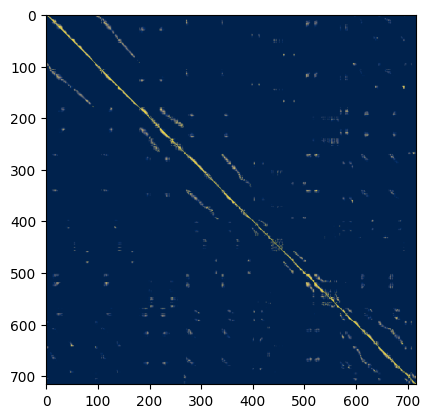

In [21]:
adj = np.load("/content/sd_rn_adj.npy")
fig, ax = plt.subplots()

ax.imshow(adj, aspect=1, cmap="cividis");

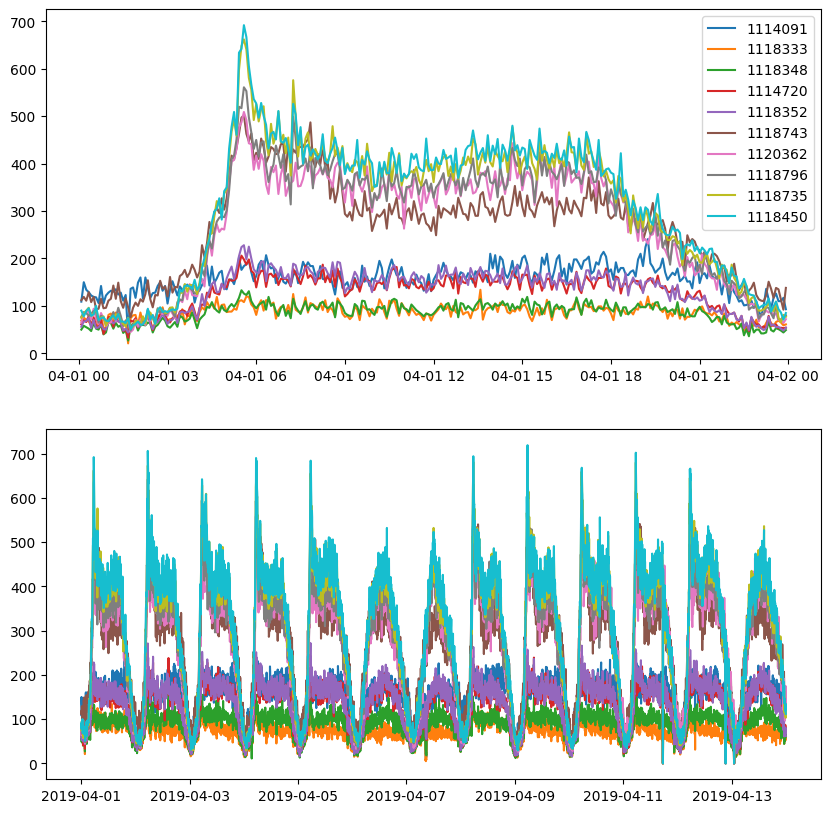

In [10]:
fig, ax = plt.subplots(2,figsize=(10,10))
#fig.autofmt_xdate()

sensorselection = list(data.columns[:10])
date = (data.index>datetime(2019,4,1)) & (data.index<datetime(2019,4,2))
week = (data.index>datetime(2019,4,1)) & (data.index<datetime(2019,4,14))

for sensor in sensorselection:
  ax[0].plot(data[sensor][date], label=sensor)
  ax[1].plot(data[sensor][week], label=sensor);


ax[0].legend(loc="best")

In [11]:
print("Shape:", data.shape)
print("\nTime range:")
print(data.index.min(), "→", data.index.max())

print("\nMissing values:")
print(data.isna().sum().sum())

print("\nNumber of sensors:", data.shape[1])
print("Number of timesteps:", data.shape[0])

print("\nData types:")
print(data.dtypes.value_counts())



Shape: (105120, 716)

Time range:
2019-01-01 00:00:00 → 2019-12-31 23:55:00

Missing values:
0

Number of sensors: 716
Number of timesteps: 105120

Data types:
float64    716
Name: count, dtype: int64


In [22]:
data_filled = data.copy()
data_filled.columns = data_filled.columns.astype(str)
meta["ID"] = meta["ID"].astype(str)

print("data_filled ready:", data_filled.shape)


data_filled ready: (105120, 716)


In [23]:
import torch
import torch.nn as nn
#from torch.utils.data import Dataset, DataLoader

WINDOW = 12          # past 12 * 5min = 1 hour of history
HORIZON = 1          # predict next timestep

values = data_filled.values.astype("float32")  # shape: (timesteps, n_sensors)

# Normalize using train-portion stats only (defined after split, see below)
n = len(values)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

mean = values[:train_end].mean(axis=0)
std = values[:train_end].std(axis=0) + 1e-6
values_norm = (values - mean) / std

print("Data shape : ", values.shape)
print("Normalized data shape : ", values_norm.shape)

Data shape :  (105120, 716)
Normalized data shape :  (105120, 716)


In [24]:
# Traffic history settings

DAY_LAG = 288       # 24 hours ago
WEEK_LAG = 2016     # 7 days ago

# Check that we have enough data
print("24-hour lag:", DAY_LAG, "time steps")
print("7-day lag:", WEEK_LAG, "time steps")

# Example: values_norm[2016] is the traffic from 7 days before
print("Example daily lag shape:", values_norm[DAY_LAG].shape)
print("Example weekly lag shape:", values_norm[WEEK_LAG].shape)

24-hour lag: 288 time steps
7-day lag: 2016 time steps
Example daily lag shape: (716,)
Example weekly lag shape: (716,)


In [25]:
# Step 3: Create forecasting features

WINDOW = 12
DAY_LAG = 288
WEEK_LAG = 2016

# The first prediction can only happen after 7 days
start_index = WEEK_LAG

# Number of prediction samples
num_samples = len(values_norm) - start_index - 1

print("Number of samples:", num_samples)

# Check the size of one input
recent_size = WINDOW * 716
daily_size = 716
weekly_size = 716

total_features = recent_size + daily_size + weekly_size

print("Recent traffic features:", recent_size)
print("24-hour lag features:", daily_size)
print("7-day lag features:", weekly_size)
print("Total features per sample:", total_features)
print("Target size:", 716)

Number of samples: 103103
Recent traffic features: 8592
24-hour lag features: 716
7-day lag features: 716
Total features per sample: 10024
Target size: 716


In [26]:
print(meta.columns.tolist())
print(meta.shape)
meta.head()

['ID', 'Lat', 'Lng', 'District', 'County', 'Fwy', 'Lanes', 'Type', 'Direction', 'ID2']
(716, 10)


,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935


In [27]:
# Check meta has an ID column matching data's sensor IDs
print(meta.iloc[:, 0].head())          # whatever the ID column is called
print(data_filled.columns[:5])         # sensor IDs from your traffic data

# Reindex meta to match data's column order exactly
meta_id_col = "ID"  # confirmed from meta.columns above
meta_aligned = meta.set_index(meta_id_col).loc[data_filled.columns]
print(meta_aligned.shape)  # should be (716, n_meta_features)

0    1114091
1    1118333
2    1118348
3    1114720
4    1118352
Name: ID, dtype: object
Index(['1114091', '1118333', '1118348', '1114720', '1118352'], dtype='object')
(716, 9)


In [28]:
# Example — adjust column names once you see meta.columns
numeric_meta_cols = ["Lat", "Lng", "Lanes"]
# District / Fwy / Direction / Type were the metadata columns called out
categorical_meta_cols = [c for c in ["District", "Fwy", "Direction", "Type"] if c in meta_aligned.columns]

meta_numeric = meta_aligned[numeric_meta_cols].values.astype("float32")  # (716, n_numeric)

if categorical_meta_cols:
    meta_categorical = pd.get_dummies(meta_aligned[categorical_meta_cols]).values.astype("float32")
    meta_features = np.concatenate([meta_numeric, meta_categorical], axis=1)
else:
    meta_features = meta_numeric

print(meta_features.shape)  # (716, n_meta_features_total)

(716, 35)


In [29]:
meta_mean = meta_features.mean(axis=0)
meta_std = meta_features.std(axis=0) + 1e-6
meta_features_norm = (meta_features - meta_mean) / meta_std

In [30]:
meta_flat = meta_features_norm.flatten()   # (716 * n_meta_features,) — same for every sample

def add_meta_features(X, meta_flat):
    meta_tiled = np.tile(meta_flat, (X.shape[0], 1))   # repeat for every row
    return np.concatenate([X, meta_tiled], axis=1)


In [31]:
hour = data_filled.index.hour.values.astype("float32")
dow = data_filled.index.dayofweek.values.astype("float32")

hour_sin = np.sin(2 * np.pi * hour / 24).astype("float32")
hour_cos = np.cos(2 * np.pi * hour / 24).astype("float32")
dow_sin = np.sin(2 * np.pi * dow / 7).astype("float32")
dow_cos = np.cos(2 * np.pi * dow / 7).astype("float32")
is_weekend = (dow >= 5).astype("float32")

time_features = np.stack([hour_sin, hour_cos, dow_sin, dow_cos, is_weekend], axis=1)
print("Time feature matrix:", time_features.shape, "(hour_sin, hour_cos, dow_sin, dow_cos, is_weekend)")


Time feature matrix: (105120, 5) (hour_sin, hour_cos, dow_sin, dow_cos, is_weekend)


In [32]:
hour = data_filled.index.hour.to_numpy()
dow = data_filled.index.dayofweek.to_numpy()          # 0=Monday ... 6=Sunday
is_weekend = (dow >= 5).astype("float32")

print("hour range:", hour.min(), "-", hour.max())
print("dow range :", dow.min(), "-", dow.max())
print("weekend share:", is_weekend.mean().round(3))


hour range: 0 - 23
dow range : 0 - 6
weekend share: 0.285


In [33]:
from numpy.lib.stride_tricks import sliding_window_view

ROLL_LONG = 72  # 6 hours, for a slower rolling average / trend signal

# Sliding windows over the whole normalized series
windows = sliding_window_view(values_norm, WINDOW, axis=0)         # (n-WINDOW+1, n_sensors, WINDOW)
windows_long = sliding_window_view(values_norm, ROLL_LONG, axis=0)  # (n-ROLL_LONG+1, n_sensors, ROLL_LONG)

targets = np.arange(start_index, start_index + num_samples)  # target time indices (from Step 3 cell)

recent = windows[targets - WINDOW]                                  # (num_samples, n_sensors, WINDOW) - 1h history
recent_flat = recent.transpose(0, 2, 1).reshape(len(targets), -1)   # flattened, time-major

daily_lag = values_norm[targets - DAY_LAG]     # 24-hour lag
weekly_lag = values_norm[targets - WEEK_LAG]   # 7-day lag

roll_short = recent.mean(axis=2)                              # 1h rolling average
roll_long = windows_long[targets - ROLL_LONG].mean(axis=2)     # 6h rolling average
trend = roll_short - roll_long                                 # traffic trend (recent vs. longer-term)

time_feat = np.stack([hour[targets].astype("float32"),
                       dow[targets].astype("float32"),
                       is_weekend[targets]], axis=1)

X = np.concatenate([recent_flat, daily_lag, weekly_lag, roll_short, trend, time_feat], axis=1).astype("float32")
y = values_norm[targets].astype("float32")  # normalized target (denormalized with mean/std at eval time)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (103103, 11459)
y shape: (103103, 716)


In [36]:
train_mask = targets < train_end
val_mask = (targets >= train_end) & (targets < val_end)
test_mask = targets >= val_end

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])


Train samples: 82080
Validation samples: 10512
Test samples: 10511


In [37]:
X_train_full = add_meta_features(X_train, meta_flat)
X_val_full = add_meta_features(X_val, meta_flat)
X_test_full = add_meta_features(X_test, meta_flat)

print(X_train_full.shape)  # (n_train_samples, base_features + 716*n_meta_features)


(82080, 36519)


In [38]:
class TrafficDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TrafficDataset(X_train_full, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TrafficDataset(X_val_full, y_val), batch_size=256, shuffle=False)
test_loader  = DataLoader(TrafficDataset(X_test_full, y_test), batch_size=256, shuffle=False)

In [39]:
class TrafficMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(512, 256, 128), dropout=0.2):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

n_sensors = data_filled.shape[1]   # 716 sensors
in_dim = X_train_full.shape[1]     # recent window + lags + rolling/trend + time + tiled metadata
out_dim = HORIZON * n_sensors      # 1 * 716 = 716

device = "cuda" if torch.cuda.is_available() else "cpu"
model = TrafficMLP(in_dim, out_dim).to(device)

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

In [41]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1:2d} | train MSE: {train_loss:.4f} | val MSE: {val_loss:.4f}")

Epoch  1 | train MSE: 0.2300 | val MSE: 0.1373
Epoch  2 | train MSE: 0.1161 | val MSE: 0.1321
Epoch  3 | train MSE: 0.1040 | val MSE: 0.1276
Epoch  4 | train MSE: 0.0976 | val MSE: 0.1114
Epoch  5 | train MSE: 0.0930 | val MSE: 0.1257
Epoch  6 | train MSE: 0.0908 | val MSE: 0.1032
Epoch  7 | train MSE: 0.0878 | val MSE: 0.1028
Epoch  8 | train MSE: 0.0857 | val MSE: 0.1046
Epoch  9 | train MSE: 0.0847 | val MSE: 0.0938
Epoch 10 | train MSE: 0.0836 | val MSE: 0.0957
Epoch 11 | train MSE: 0.0822 | val MSE: 0.0972
Epoch 12 | train MSE: 0.0817 | val MSE: 0.0879
Epoch 13 | train MSE: 0.0815 | val MSE: 0.0893
Epoch 14 | train MSE: 0.0809 | val MSE: 0.0979
Epoch 15 | train MSE: 0.0800 | val MSE: 0.0941
Epoch 16 | train MSE: 0.0790 | val MSE: 0.0962
Epoch 17 | train MSE: 0.0797 | val MSE: 0.0864
Epoch 18 | train MSE: 0.0788 | val MSE: 0.0932
Epoch 19 | train MSE: 0.0791 | val MSE: 0.0936
Epoch 20 | train MSE: 0.0782 | val MSE: 0.0830


In [42]:
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb.to(device)).cpu().numpy()
        preds.append(pred)
        actuals.append(yb.numpy())

n_sensors_actual = data.shape[1] # Use the actual number of sensors
preds = np.concatenate(preds).reshape(-1, HORIZON, n_sensors_actual) * std + mean
actuals = np.concatenate(actuals).reshape(-1, HORIZON, n_sensors_actual) * std + mean

mae = np.mean(np.abs(preds - actuals))
rmse = np.sqrt(np.mean((preds - actuals) ** 2))
print(f"Test MAE: {mae:.3f}, RMSE: {rmse:.3f}")

Test MAE: 28.959, RMSE: 43.715


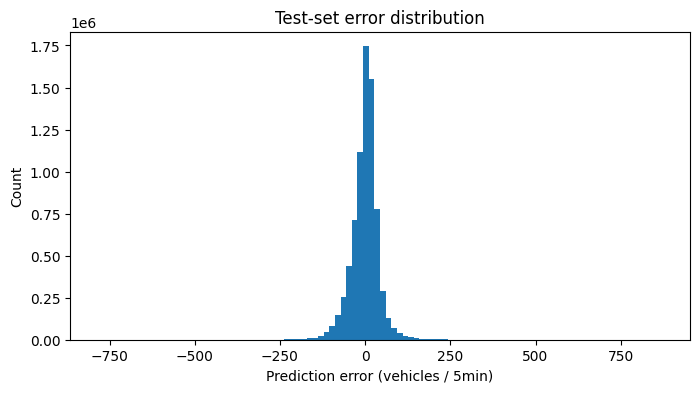

In [43]:
plt.figure(figsize=(8, 4))
plt.hist((preds - actuals).flatten(), bins=100)
plt.xlabel("Prediction error (vehicles / 5min)")
plt.ylabel("Count")
plt.title("Test-set error distribution")
plt.show()


In [45]:
# Check meta has an ID column matching data's sensor IDs
print(meta.iloc[:, 0].head())          # whatever the ID column is called
print(data_filled.columns[:5])         # sensor IDs from your traffic data

# Reindex meta to match data's column order exactly
meta_id_col = "ID"  # <- replace with actual column name once you see it
meta_aligned = meta.set_index(meta_id_col).loc[data_filled.columns]
print(meta_aligned.shape)  # should be (716, n_meta_features)

0    1114091
1    1118333
2    1118348
3    1114720
4    1118352
Name: ID, dtype: object
Index(['1114091', '1118333', '1118348', '1114720', '1118352'], dtype='object')
(716, 9)


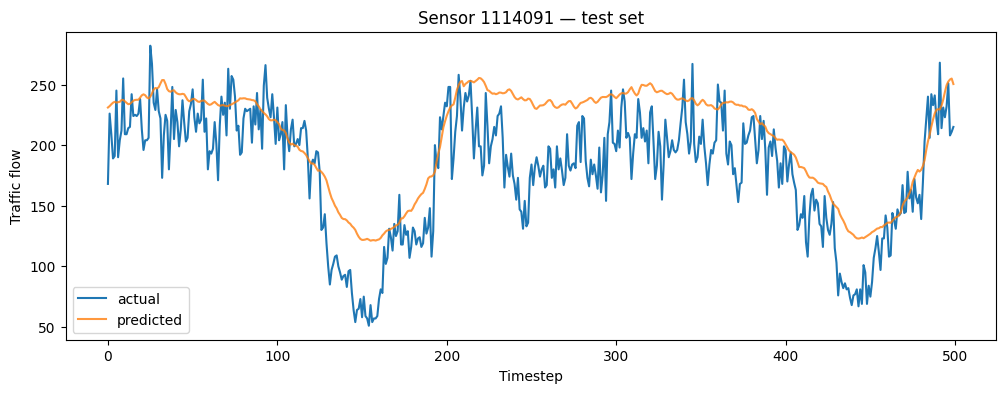

In [53]:
sensor_i = 0
n_show = 500  # first ~1.7 days of the test period

plt.figure(figsize=(12, 4))
plt.plot(actuals[:n_show, 0, sensor_i], label="actual")
plt.plot(preds[:n_show, 0, sensor_i], label="predicted", alpha=0.8)
plt.title(f"Sensor {data_filled.columns[sensor_i]} — test set")
plt.xlabel("Timestep")
plt.ylabel("Traffic flow")
plt.legend()
plt.show()


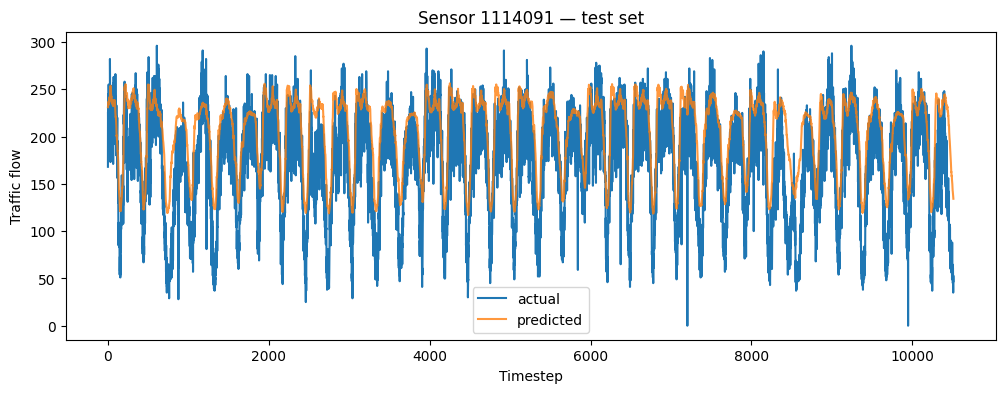

In [54]:
sensor_i = 0
n_show = 24*5*365  # a year
plt.figure(figsize=(12, 4))
plt.plot(actuals[:n_show, 0, sensor_i], label="actual")
plt.plot(preds[:n_show, 0, sensor_i], label="predicted", alpha=0.8)
plt.title(f"Sensor {data_filled.columns[sensor_i]} — test set")
plt.xlabel("Timestep")
plt.ylabel("Traffic flow")
plt.legend()
plt.show()


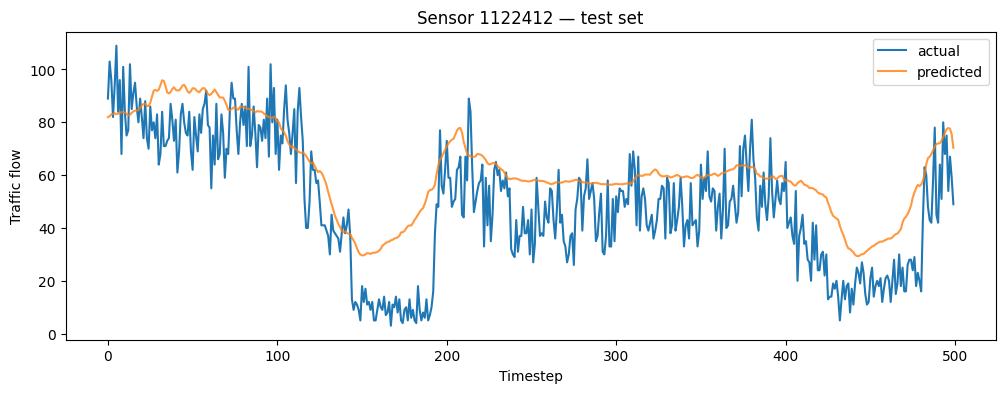

In [55]:
sensor_i = 715
n_show = 500  # first ~1.7 days of the test period

plt.figure(figsize=(12, 4))
plt.plot(actuals[:n_show, 0, sensor_i], label="actual")
plt.plot(preds[:n_show, 0, sensor_i], label="predicted", alpha=0.8)
plt.title(f"Sensor {data_filled.columns[sensor_i]} — test set")
plt.xlabel("Timestep")
plt.ylabel("Traffic flow")
plt.legend()
plt.show()


Plotting all 716 sensors, each with 10511 timesteps, on a single figure.


/tmp/ipykernel_1119/3204179039.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


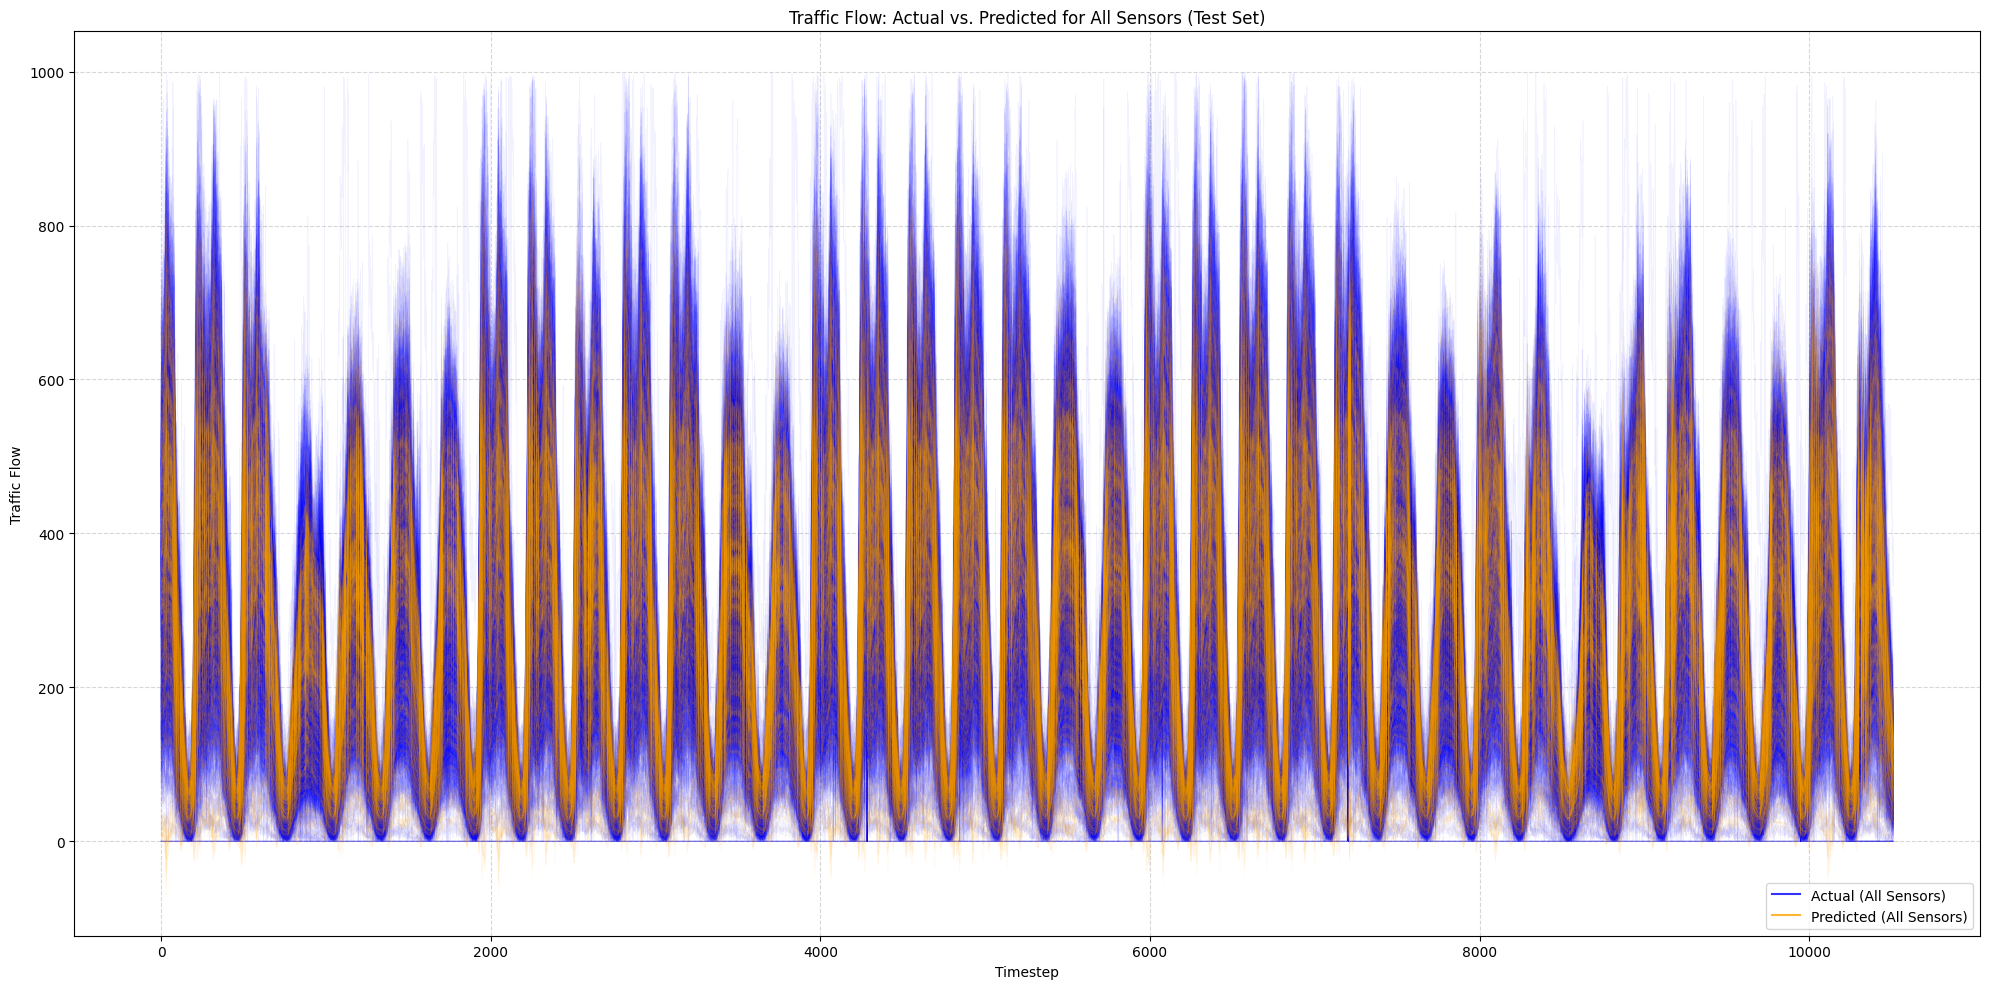

In [49]:
num_timesteps_to_show = actuals.shape[0]  # Plot the full test period
num_sensors_to_plot = n_sensors_actual # Plot all 716 sensors

print(f"Plotting all {num_sensors_to_plot} sensors, each with {num_timesteps_to_show} timesteps, on a single figure.\nWarning: This plot will be very dense and potentially difficult to read due to the large number of overlapping lines.")

plt.figure(figsize=(20, 10)) # Increased figure size for more room

# Plot actuals for all sensors
for sensor_idx in range(num_sensors_to_plot):
    plt.plot(actuals[:num_timesteps_to_show, 0, sensor_idx], color='blue', alpha=0.05, linewidth=0.5)

# Plot predictions for all sensors
for sensor_idx in range(num_sensors_to_plot):
    plt.plot(preds[:num_timesteps_to_show, 0, sensor_idx], color='orange', alpha=0.05, linewidth=0.5)

# Add proxy lines for the legend so it doesn't show 1432 individual labels
plt.plot([], [], color='blue', alpha=0.8, label="Actual (All Sensors)")
plt.plot([], [], color='orange', alpha=0.8, label="Predicted (All Sensors)")

plt.title("Traffic Flow: Actual vs. Predicted for All Sensors (Test Set)")
plt.xlabel("Timestep")
plt.ylabel("Traffic Flow")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()